In [2]:
import pandas as pd

df = pd.read_csv("../data/Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Month-Year"] = df["Order Date"].dt.to_period("M")
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Month-Year            period[M]
dtype: object

In [8]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()

In [9]:
df["Profit_Margin"] = df["Profit"] / df["Sales"]

In [10]:
df[["Sales", "Profit", "Profit_Margin"]].head()

,Sales,Profit,Profit_Margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales
total_orders = df["Order ID"].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Overall Profit Margin:", round(profit_margin * 100, 2), "%")
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Overall Profit Margin: 12.47 %
Total Orders: 5009
Average Order Value: 458.61


In [12]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009
Total Customers: 793


In [13]:
df.groupby("Category")[["Sales", "Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [14]:
category = df.groupby("Category")[["Sales","Profit"]].sum()
category["Profit Margin %"] = (category["Profit"] / category["Sales"]) * 100
category

,Sales,Profit,Profit Margin %
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


Technology is the most profitable category.
Furniture generates strong sales but low profit thus it is a problem.
Office Supplies shows stable margins.

In [15]:
df.groupby("Region")[["Sales", "Profit"]].sum()

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [16]:
region = df.groupby("Region")[["Sales","Profit"]].sum()
region["Profit Margin %"] = (region["Profit"] / region["Sales"]) * 100
region

,Sales,Profit,Profit Margin %
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


West region leads in both profit and sales.

Central region shows weaker margin performance.

In [17]:
df.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

In [18]:
df.groupby("Region")["Discount"].mean().sort_values(ascending=False)

Region
Central    0.240353
South      0.147253
East       0.145365
West       0.109335
Name: Discount, dtype: float64

In [27]:
losses = df[df["Profit"] < 0]

losses_by_region = losses.groupby("Region")["Profit"].count()
losses_by_region

Region
Central    741
East       553
South      259
West       318
Name: Profit, dtype: int64

In [28]:
losses.groupby("Region")["Profit"].sum()

Region
Central   -56314.8850
East      -49590.6075
South     -27504.8323
West      -22720.9609
Name: Profit, dtype: float64

Discounts above 20% result in negative profitability.

Central has the highest discounts. it gives almost two times more than West. THIS CONFIRMS HIGH DISCOUNTS ARE ERODING PROFITABILITY.

High discount levels significantly reduce margins.

               VISUALIZATION

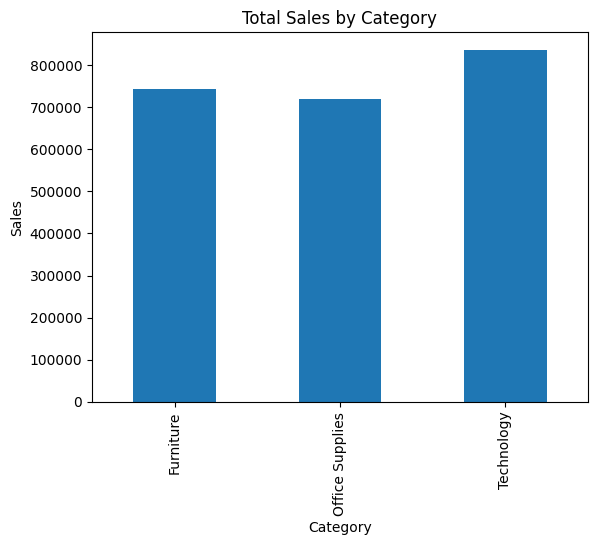

In [19]:
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

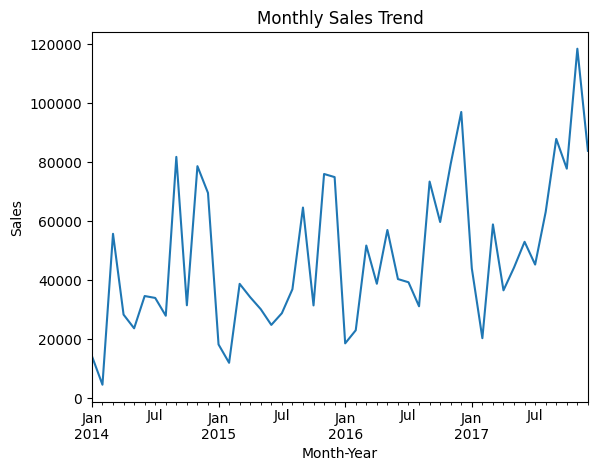

In [20]:
monthly = df.groupby("Month-Year")["Sales"].sum()
monthly.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")
plt.show()

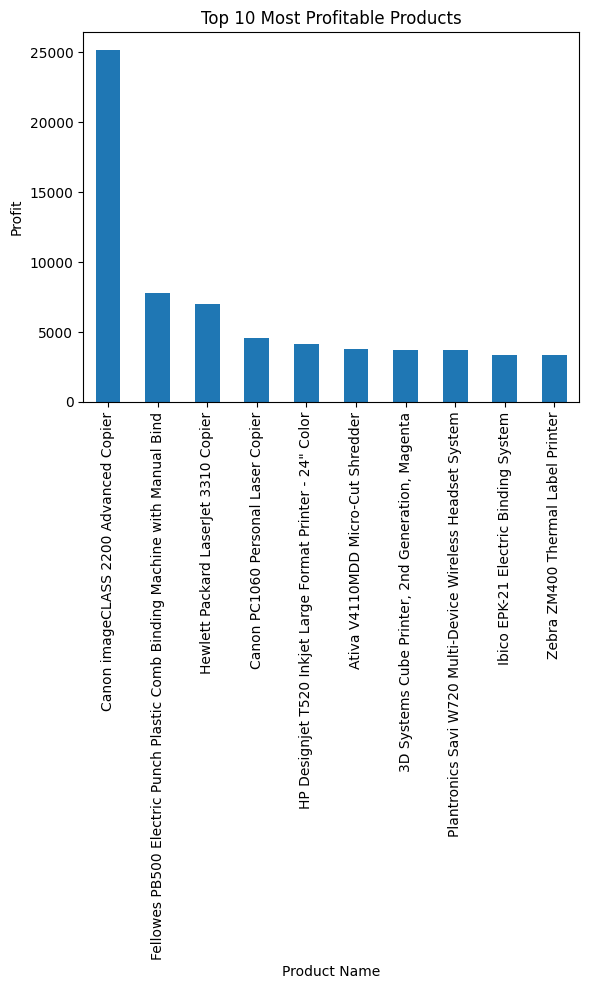

In [21]:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top 10 Most Profitable Products")
plt.ylabel("Profit")
plt.show()

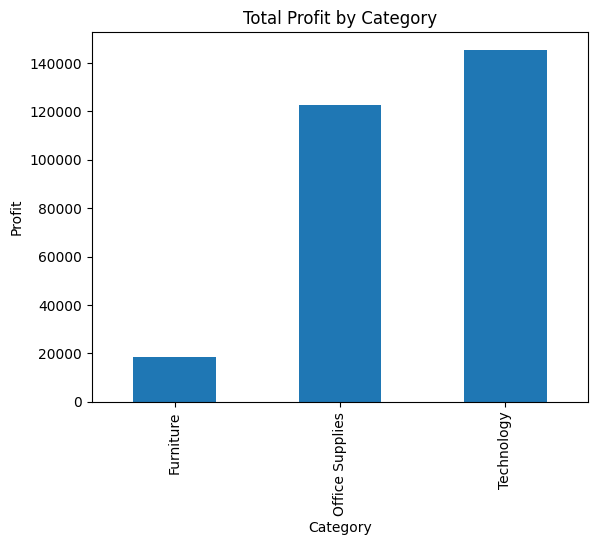

In [22]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

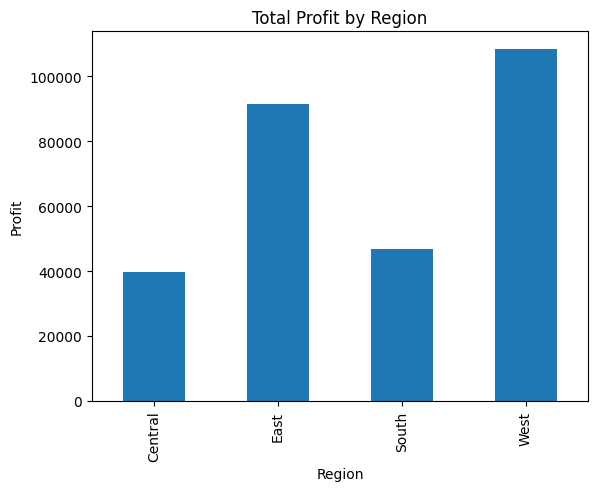

In [23]:
df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

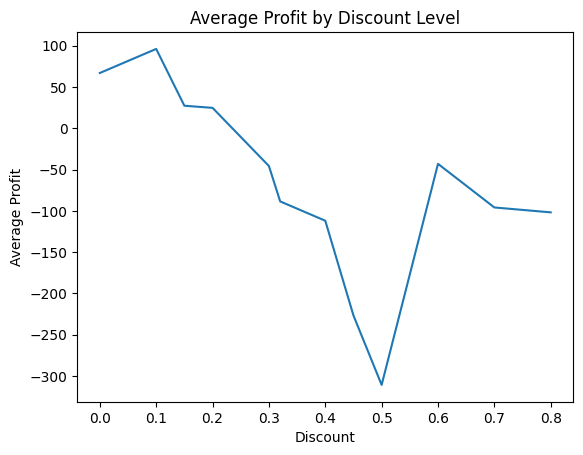

In [24]:
df.groupby("Discount")["Profit"].mean().plot(kind="line")
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

In [25]:
df.to_csv("cleaned_superstore.csv", index=False)

The analysis reveals that while the business generates strong revenue, profitability is significantly affected by aggressive discounting beyond 20%. The Furniture category requires strategic restructuring due to its low margin performance. Growth should focus on Technology and West region operations, while discount governance and pricing optimization are critical to improving overall profit margins from 12.47% to a targeted 15–18%.

BUSINESS RECOMMENDATIONS

Reduce Aggressive Discounting in Central - Implement discount cap at 20%. This will lead to immediate improvement in profit margin.

 Audit High-Discount Furniture Products - especially in Central region.

 Review Orders with 30%+ Discounts